# Lab 1 — Classic XAI: SHAP & LIME on a Black-Box Model

**Estimated time:** ~20 minutes  
**Level:** Basic-intermediate Python, some ML familiarity helpful

---

## What you will learn

1. Train a **black-box** Random Forest classifier on a real dataset.
2. Understand **what SHAP calculates** and visualise the game-theory mechanics behind it.
3. Understand **what LIME calculates** and visualise the local-approximation mechanics behind it.
4. **Compare** the two methods and reflect on whether we can trust them fully.

---

## The dataset — Breast Cancer Wisconsin

The [Breast Cancer Wisconsin dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset) contains **569 samples** with **30 numeric features** describing cell nuclei in digitised images of fine-needle aspirates of a breast mass.  
The target is binary: **malignant (0)** or **benign (1)**.

It is a deliberately hard problem for a human to solve without assistance — a perfect candidate for black-box explanation.

## 0. Setup — install & import

In [9]:
# Run once to install missing packages
import subprocess, sys
packages = ["shap", "lime"]
for pkg in packages:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("All packages available.")

All packages available.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

import shap
import lime
import lime.lime_tabular

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
SEED = 42
print("Imports OK.")

Imports OK.


---
## 1. Load & Explore the Data

In [11]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign

print(f"Dataset shape: {X.shape}")
print(f"Classes: {dict(zip(data.target_names, np.bincount(y)))}")

# Show the first five rows with a subset of features
display(X.iloc[:, :6].join(y).head())

Dataset shape: (569, 30)
Classes: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0


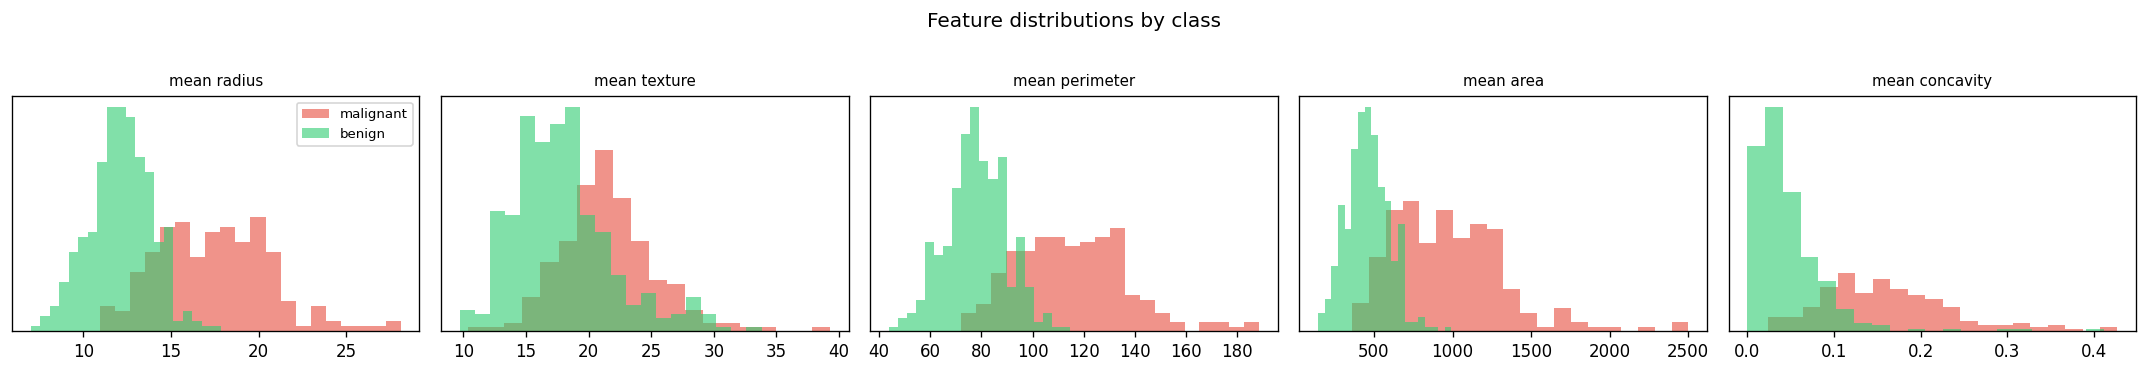

In [12]:
# Quick look at five important features
top_features = ["mean radius", "mean texture", "mean perimeter",
                "mean area", "mean concavity"]

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, feat in zip(axes, top_features):
    for label, colour in zip([0, 1], ["#e74c3c", "#2ecc71"]):
        ax.hist(X.loc[y == label, feat], bins=20, alpha=0.6,
                color=colour, label=data.target_names[label])
    ax.set_title(feat, fontsize=9)
    ax.set_yticks([])
axes[0].legend(fontsize=8)
fig.suptitle("Feature distributions by class", y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Train a Black-Box Model

We deliberately choose a **Random Forest** — a strong, accurate model that is **not inherently interpretable**: its decisions emerge from hundreds of decision trees voting together.  
This is exactly the kind of model where post-hoc explanation tools like SHAP and LIME add value.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=SEED)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Test accuracy: 0.956

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



> **~96 % accuracy** — great model, but how does it decide? Let's find out.

---
## 3. SHAP — SHapley Additive exPlanations

### 3a. What exactly does SHAP calculate?

SHAP is rooted in **cooperative game theory**.  
The key idea: treat each feature as a *player* in a game whose *payout* is the model prediction.  
The **Shapley value** of a feature is its **fair share** of the total payout, averaged over all possible orderings in which features could have joined the coalition.

Formally, for feature $i$:

$$
\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!}
\left[ f(S \cup \{i\}) - f(S) \right]
$$

where $F$ is the full set of features and $f(S)$ is the model's expected output when only features in $S$ are known.

The cell below draws an intuitive picture of this process.

### 3b. Compute SHAP values

In [16]:
# TreeExplainer is optimised for tree-based models (RF, XGBoost, …)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# shap_values[1] = contributions toward class 1 (benign)
print(f"SHAP values shape: {np.array(shap_values).shape}")

SHAP values shape: (114, 30, 2)


### 3c. Visualise — global feature importance

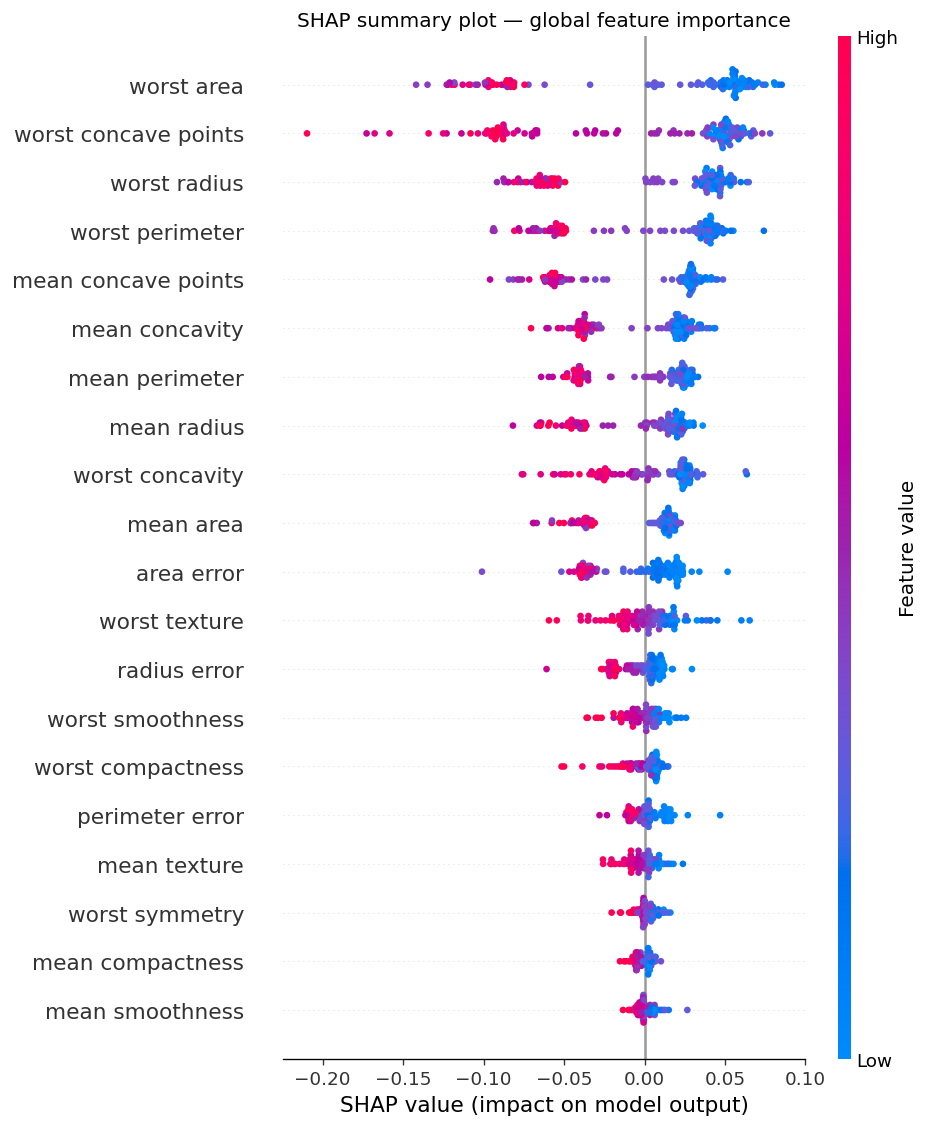

In [18]:
# Summary plot: each dot is one test sample.
# Colour = feature value (high=red, low=blue).
# Position on x-axis = SHAP value (impact on model output).
plt.figure()
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="dot",
                  feature_names=data.feature_names, show=False)
plt.title("SHAP summary plot — global feature importance", fontsize=12)
plt.tight_layout()
plt.show()

### 3d. Visualise — single prediction (waterfall plot)

Sample 2: true = malignant, predicted = malignant


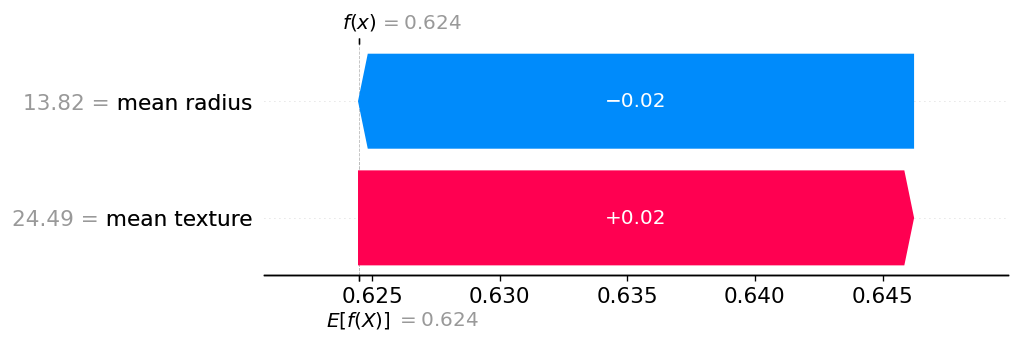

In [21]:
# Pick one test sample to explain
SAMPLE_IDX = 2

expected_value = explainer.expected_value[1]          # base value for class 1
shap_sample   = shap_values[1][SAMPLE_IDX]             # SHAP values for this sample
true_label    = data.target_names[y_test.iloc[SAMPLE_IDX]]
pred_label    = data.target_names[model.predict(X_test.iloc[[SAMPLE_IDX]])[0]]

print(f"Sample {SAMPLE_IDX}: true = {true_label}, predicted = {pred_label}")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_sample,
        base_values=expected_value,
        data=X_test.iloc[SAMPLE_IDX].values,
        feature_names=list(data.feature_names)
    ),
    max_display=10
)

### 3e. Exercise — SHAP

1. Look at the summary plot. Which **two features** have the largest positive impact on predicting *benign*? Does that make clinical sense?
2. In the waterfall plot, what is the **base value** and what does it represent?
3. Change `SAMPLE_IDX` to `0` and re-run the waterfall. Does the explanation change? Why?
4. **(Stretch)** SHAP promises **consistency**: if a model relies on feature A more than feature B, A will always receive a higher SHAP value. Why is this property important in a medical setting?

---
## 4. LIME — Local Interpretable Model-agnostic Explanations

### 4a. What exactly does LIME calculate?

LIME does not look inside the model at all.  
Instead it asks: *"Around this specific prediction, what simple linear model best describes the black box's behaviour?"*

The algorithm for one instance $x$:

1. **Perturb** — Generate $n$ synthetic neighbours of $x$ by randomly masking features.
2. **Query** — Ask the black-box model for predictions on each neighbour.
3. **Weight** — Give higher weight to neighbours that are closer to $x$ (via an exponential kernel).
4. **Fit** — Train a **sparse linear model** on the weighted (neighbour, prediction) pairs.
5. **Explain** — The linear model's coefficients are the local feature importances.

$$
\xi(x) = \arg\min_{g \in G}\; \mathcal{L}(f, g, \pi_x) + \Omega(g)
$$

where $\pi_x$ is the proximity measure around $x$, $\Omega(g)$ penalises model complexity, and $G$ is the family of interpretable models.

### 4b. Compute a LIME explanation

In [22]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(data.feature_names),
    class_names=list(data.target_names),
    mode='classification',
    random_state=SEED
)

# Explain the same sample we used for SHAP
lime_exp = lime_explainer.explain_instance(
    data_row=X_test.values[SAMPLE_IDX],
    predict_fn=model.predict_proba,
    num_features=10
)

print(f"Explaining sample {SAMPLE_IDX} — true: {true_label}, predicted: {pred_label}")

Explaining sample 2 — true: malignant, predicted: malignant


### 4c. Visualise — local bar chart

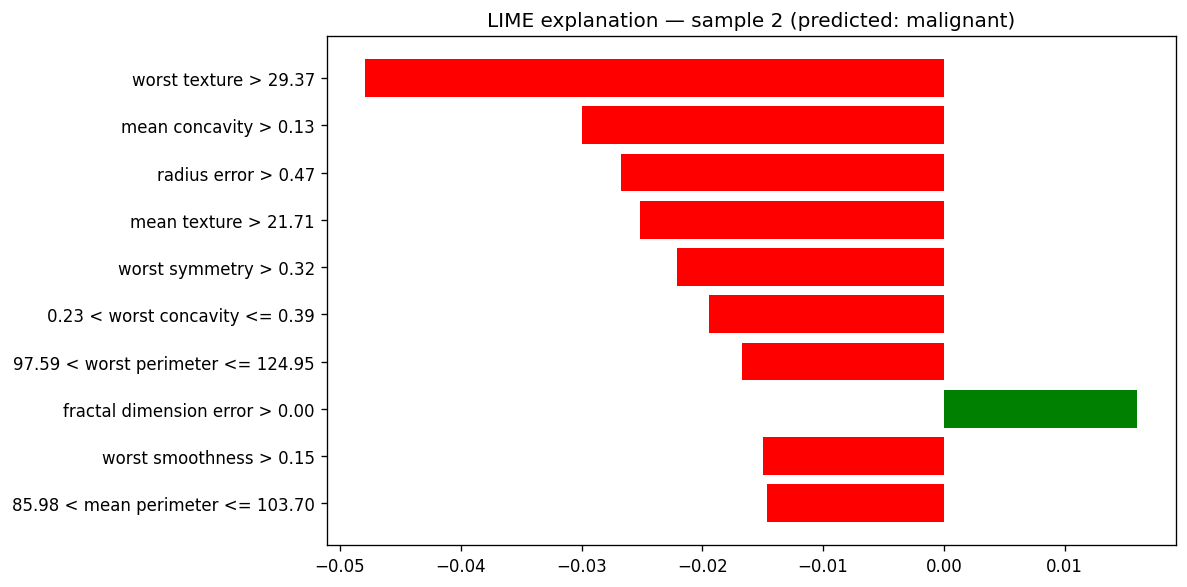

In [23]:
fig = lime_exp.as_pyplot_figure(label=1)   # label=1 → 'benign'
fig.set_size_inches(10, 5)
plt.title(f"LIME explanation — sample {SAMPLE_IDX} (predicted: {pred_label})",
          fontsize=12)
plt.tight_layout()
plt.show()

### 4d. Exercise — LIME

1. Which features are the top contributors according to LIME? Do they match the SHAP waterfall for the same sample?
2. Run the cell below to explain **five different samples** and compare the LIME explanations. What do you notice about consistency across samples?
3. LIME uses `num_features=10`. Change it to `5` and re-run — how does the explanation change?
4. **(Stretch)** LIME generates random perturbations every run. What happens to the explanation if you remove `random_state=SEED` and re-run the explainer several times?

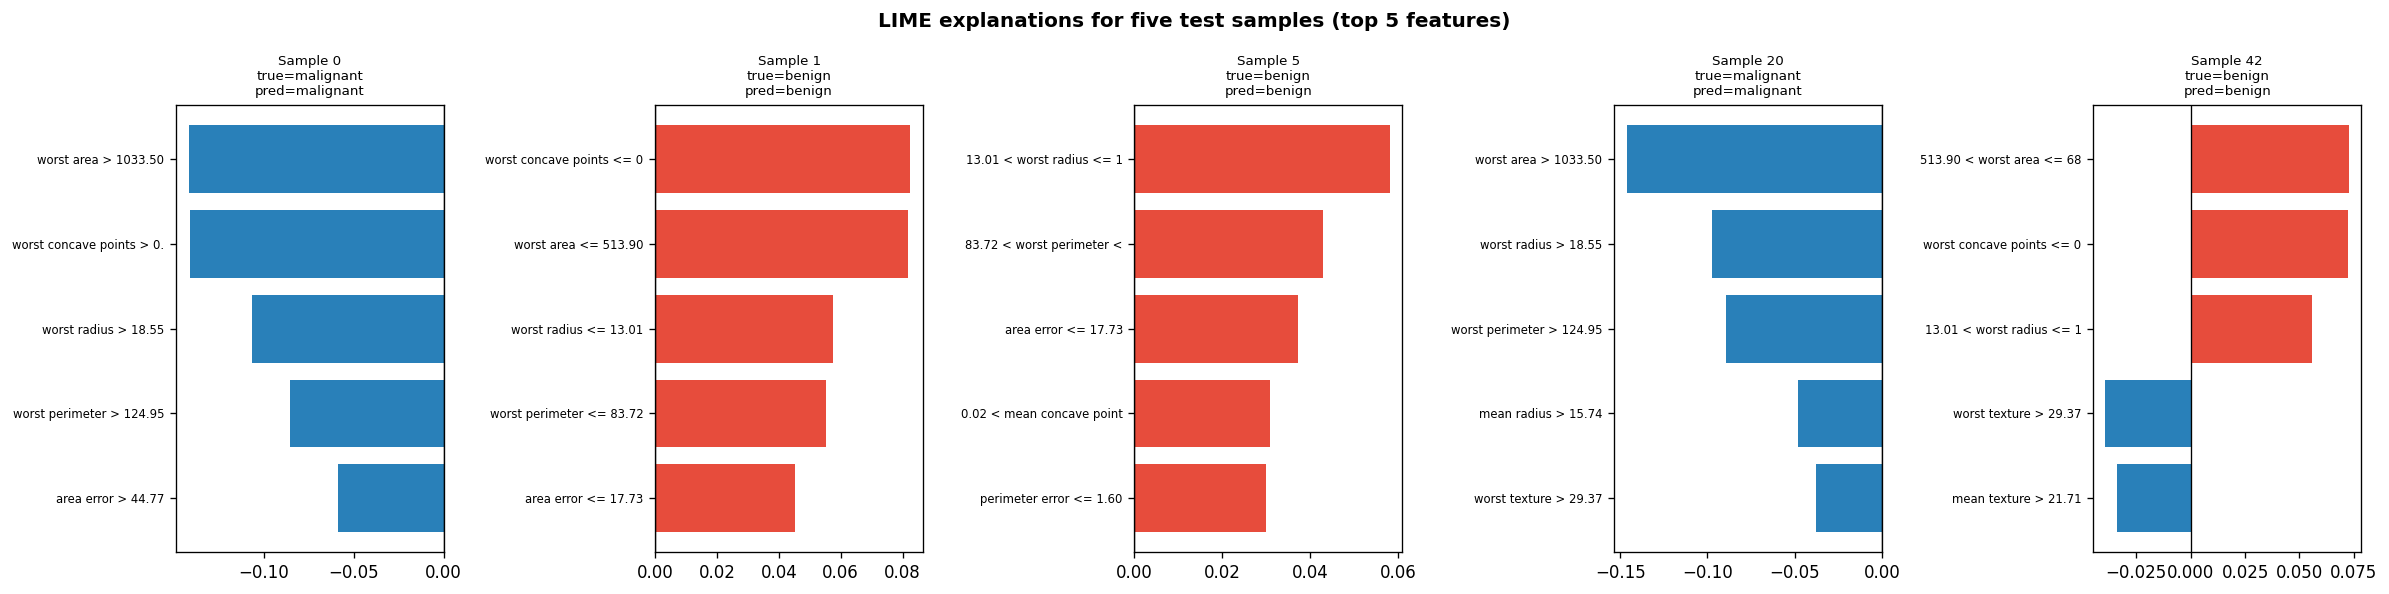

In [25]:
# Compare LIME explanations across five test samples
sample_indices = [0, 1, 5, 20, 42]

fig, axes = plt.subplots(1, len(sample_indices), figsize=(20, 5), sharey=False)

for ax, idx in zip(axes, sample_indices):
    exp = lime_explainer.explain_instance(
        data_row=X_test.values[idx],
        predict_fn=model.predict_proba,
        num_features=5
    )
    feat_vals = exp.as_list(label=1)
    names  = [fv[0][:25] for fv in feat_vals][::-1]
    values = [fv[1] for fv in feat_vals][::-1]
    colours = ["#e74c3c" if v > 0 else "#2980b9" for v in values]
    ax.barh(range(len(names)), values, color=colours)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=7)
    ax.axvline(0, color='black', lw=0.8)
    true_l = data.target_names[y_test.iloc[idx]]
    pred_l = data.target_names[model.predict(X_test.iloc[[idx]])[0]]
    ax.set_title(f"Sample {idx}\ntrue={true_l}\npred={pred_l}", fontsize=8)

fig.suptitle("LIME explanations for five test samples (top 5 features)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Exercise — SHAP vs LIME: Differences and Trust

### 5a. Side-by-side feature importance comparison

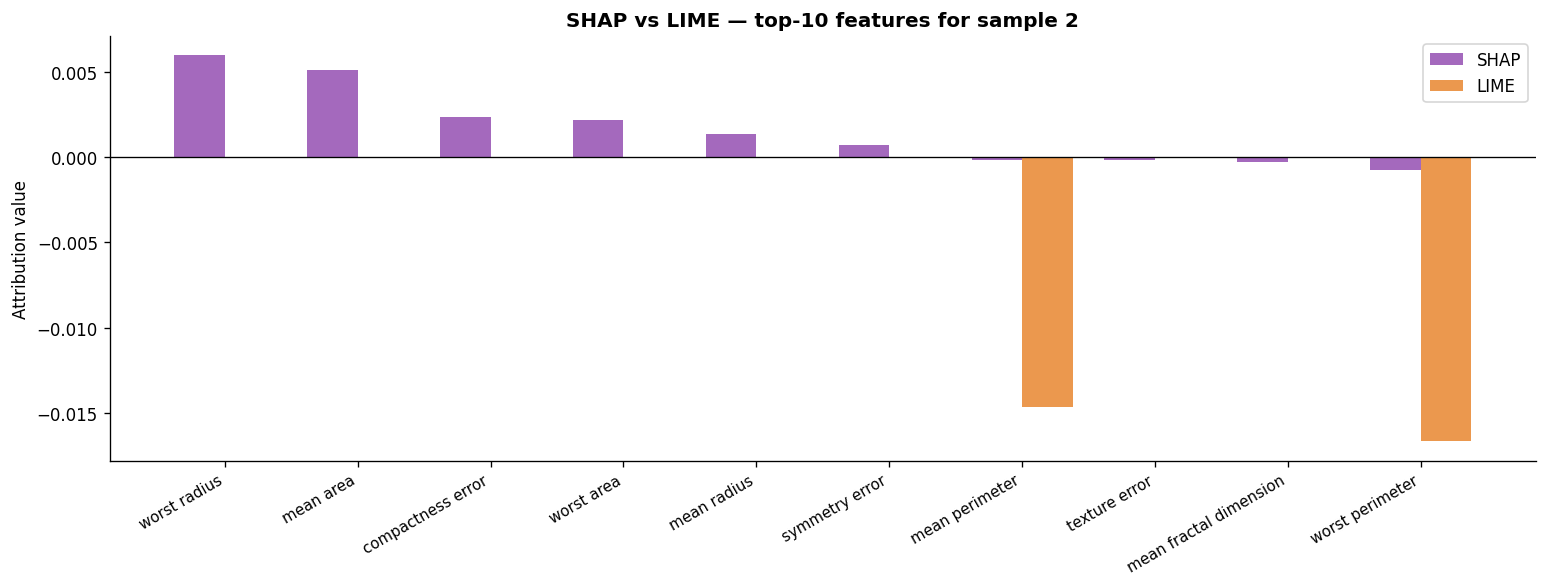


Spearman rank correlation between SHAP and LIME feature rankings:
  ρ = 0.218  (p = 0.246)


In [27]:
# Build a comparison DataFrame for sample SAMPLE_IDX
# --- SHAP importance for this sample ---
shap_df = pd.DataFrame({
    'feature': data.feature_names,
    'shap':    shap_values[SAMPLE_IDX, :, 1]
}).set_index('feature')

# --- LIME importance for this sample ---
lime_dict = dict(lime_exp.as_list(label=1))
lime_df = pd.DataFrame.from_dict(lime_dict, orient='index', columns=['lime'])

# Merge on feature name (LIME names can contain inequalities, so we do a fuzzy match)
compare_rows = []
for feat in data.feature_names:
    shap_val = shap_df.loc[feat, 'shap']
    lime_val = 0.0
    for lime_feat, val in lime_dict.items():
        if feat in lime_feat:
            lime_val = val
            break
    compare_rows.append({'feature': feat, 'SHAP': shap_val, 'LIME': lime_val})

compare_df = pd.DataFrame(compare_rows).sort_values('SHAP', ascending=False)
top10 = compare_df.head(10)

# Plot
x = np.arange(len(top10))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, top10['SHAP'], width, label='SHAP', color='#8e44ad', alpha=0.8)
bars2 = ax.bar(x + width/2, top10['LIME'], width, label='LIME', color='#e67e22', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(top10['feature'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel("Attribution value")
ax.set_title(f"SHAP vs LIME — top-10 features for sample {SAMPLE_IDX}",
             fontsize=12, fontweight='bold')
ax.axhline(0, color='black', lw=0.8)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\nSpearman rank correlation between SHAP and LIME feature rankings:")
from scipy.stats import spearmanr
corr, pval = spearmanr(compare_df['SHAP'].abs(), compare_df['LIME'].abs())
print(f"  ρ = {corr:.3f}  (p = {pval:.3f})")

### 5b. Stability test — does LIME give consistent explanations?

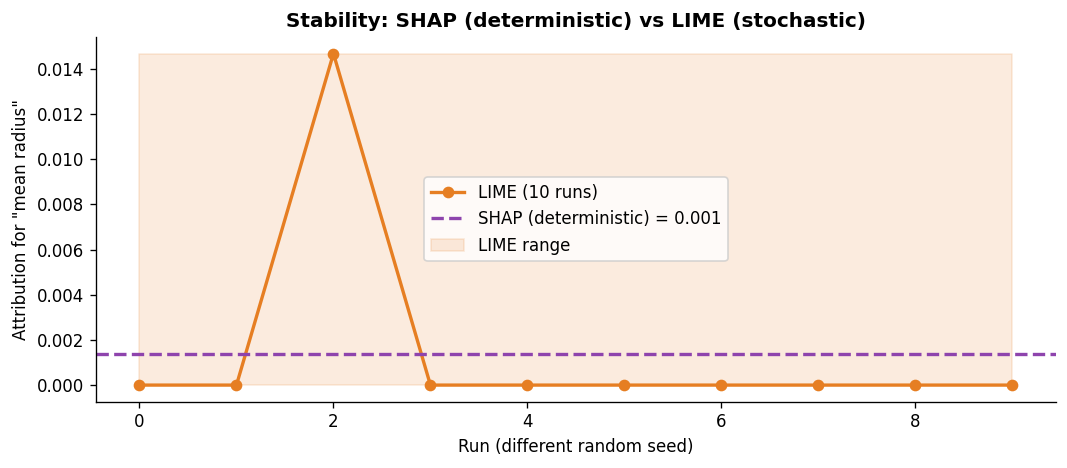

LIME range for 'mean radius': [0.0000, 0.0147]
LIME std dev: 0.0044
SHAP value:   0.0014 (same every run)


In [28]:
# Run LIME 10 times on the same sample with different random seeds
# and track how much the top feature attribution changes.
n_runs = 10
top_feature = "mean radius"  # known top feature from SHAP
lime_runs = []

for seed in range(n_runs):
    exp_tmp = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=list(data.feature_names),
        class_names=list(data.target_names),
        mode='classification',
        random_state=seed
    ).explain_instance(
        data_row=X_test.values[SAMPLE_IDX],
        predict_fn=model.predict_proba,
        num_features=10
    )
    lime_dict_tmp = dict(exp_tmp.as_list(label=1))
    val = next((v for k, v in lime_dict_tmp.items() if top_feature in k), 0.0)
    lime_runs.append(val)

# SHAP is deterministic (no randomness in TreeExplainer)
shap_val_fixed = shap_df.loc[top_feature, 'shap']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(n_runs), lime_runs, 'o-', color='#e67e22', label='LIME (10 runs)', lw=2)
ax.axhline(shap_val_fixed, color='#8e44ad', lw=2, linestyle='--',
           label=f'SHAP (deterministic) = {shap_val_fixed:.3f}')
ax.fill_between(range(n_runs),
                [min(lime_runs)]*n_runs, [max(lime_runs)]*n_runs,
                alpha=0.15, color='#e67e22', label='LIME range')
ax.set_xlabel("Run (different random seed)")
ax.set_ylabel(f'Attribution for "{top_feature}"')
ax.set_title("Stability: SHAP (deterministic) vs LIME (stochastic)",
             fontsize=12, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"LIME range for '{top_feature}': [{min(lime_runs):.4f}, {max(lime_runs):.4f}]")
print(f"LIME std dev: {np.std(lime_runs):.4f}")
print(f"SHAP value:   {shap_val_fixed:.4f} (same every run)")

### 5c. Discussion — Can we trust SHAP and LIME fully?

Run the comparison cells above, then discuss the questions below.

---

#### Key differences

| Property | SHAP | LIME |
|---|---|---|
| **Theoretical basis** | Game theory (Shapley values) | Local linear approximation |
| **Scope** | Global *and* local | Local only |
| **Model access** | Needs model internals (TreeExplainer) or many queries | Black-box: only `predict_proba` needed |
| **Determinism** | Deterministic (TreeExplainer) | Stochastic (random perturbations) |
| **Faithfulness** | Provably faithful to model (Shapley axioms) | Faithful only *locally*; the linear proxy may be wrong globally |
| **Computational cost** | $O(2^n)$ naive; $O(T \cdot D)$ with TreeExplainer | $O(n_{samples} \cdot \text{model cost})$ |
| **Feature interaction handling** | Interaction values available | Ignored (linear model) |

---

#### Discussion questions

1. **Disagreement**: SHAP and LIME sometimes rank the same features differently. *Whose ranking is "correct"?*  
   Hint: they answer slightly different questions. What are those questions?

2. **Stability**: From the stability test, how much does LIME's explanation vary across random seeds?  
   Is a medical professional supposed to trust an explanation that changes every run?

3. **Faithfulness**: LIME fits a linear model locally. What happens in regions of the feature space where the true decision boundary is highly non-linear?  
   Can you think of a way to detect when a LIME explanation is unreliable?

4. **Adversarial manipulation**: Research has shown that it is possible to build models that fool both SHAP and LIME — producing fair-looking explanations for biased models.  
   What does this tell us about using XAI explanations as *the only* accountability mechanism?

5. **Your verdict**: Given the differences and limitations above, would you use SHAP, LIME, or both in a production system that affects patients' treatment decisions? Why?

---

> **Take-away**: SHAP and LIME are powerful *tools for understanding models*, but they are not a substitute for rigorous model validation, fairness auditing, and human oversight.  
> They explain the model — not reality. Always ask: *"Is this model worth explaining in the first place?"*